# Antisaccade experiment analysis with pyxations

Parses WebGazer CSVs, converts to BIDS, runs REMoDNaV,
and propagates trial metadata via `behavioral_columns`.


## 0. Setup

In [1]:
# IMPORTANT: use python3.10
# In terminal: python3.10 -m jupyter notebook

# Install pyxations from local source (uncomment on first run):
!pip install -e /home/gus/Documents/REPOS/pyxations

from pathlib import Path
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.feather as feather

import pyxations as pyx

print('pyxations', pyx.__version__ if hasattr(pyx, '__version__') else 'OK')

REPO_ROOT = Path('.').resolve().parent  # notebook lives inside the experiment subfolder
print(f'Working dir: {REPO_ROOT}')


Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///home/gus/Documents/REPOS/pyxations
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for pyxations (pyproject.toml) ... done
  Created wheel for pyxations: filename=pyxations-0.2.9-py3-none-any.whl size=4095 sha256=e2441f6f4cca63e23955d8a47e24fded66ad244657e5c327f99ee52d1757513f
  Stored in directory: /tmp/pip-ephem-wheel-cache-bh9x4z7v/wheels/17/0e/fc/69026a9c7df2d51824e72c9663e35863f9e2f79ae3d115a91f
Successfully built pyxations
  Attempting uninstall: pyxations
    Found existing installation: pyxations 0.2.9
    Uninstalling pyxations-0.2.9:
      Successfully uninstalled pyxations-0.2.9

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, ru

### 1 Prepare files for pyxations

pyxations expects files named `{subject_id}_{...}.csv` (subject first).
Original files are `antisacadas_{subject_id}.csv` — need to be renamed.
We make copies in a temporary directory — **originals are not modified**.


In [2]:
RAW_ANTI = REPO_ROOT / "antisaccade_experiment" / "raw_data"
ANTI_STAGING = REPO_ROOT / "antisaccade_experiment" / "_staging"  # temporary
ANTI_STAGING.mkdir(exist_ok=True)

for csv_file in RAW_ANTI.glob("antisacadas_*.csv"):
    subject_id = csv_file.stem.split("_")[1]       # "100", "101", ...
    new_name = f"{subject_id}_antisacadas.csv"      # "100_antisacadas.csv"
    dest = ANTI_STAGING / new_name
    if not dest.exists():
        shutil.copy(csv_file, dest)

print(f"Files prepared: {len(list(ANTI_STAGING.glob('*.csv')))} subjects")
print([f.name for f in sorted(ANTI_STAGING.glob('*.csv'))[:5]])


Files prepared: 26 subjects
['100_antisacadas.csv', '101_antisacadas.csv', '102_antisacadas.csv', '103_antisacadas.csv', '104_antisacadas.csv']


### 2 Convert to BIDS

In [3]:
ANTI_BIDS = REPO_ROOT / "antisaccade_experiment" / "bids"

bids_path = pyx.dataset_to_bids(
    target_folder_path=ANTI_BIDS,
    files_folder_path=ANTI_STAGING,
    dataset_name="antisaccade",
    session_substrings=1,
    format_name="webgazer",
)

print(f"BIDS created at: {bids_path}")

participants = pd.read_csv(bids_path / "participants.tsv", sep="\t")
print(f"\nParticipants ({len(participants)}):")
print(participants.head())


BIDS created at: /home/gus/Documents/REPOS/et_webcam_experiments/antisaccade_experiment/bids/antisaccade

Participants (26):
   subject_id  old_subject_id
0           1              91
1           2              92
2           3              98
3           4              99
4           5             100


### 3 Compute derivatives (fixation and saccade detection)

Replaces the `os.system("remodnav ...")` loop that generated ~1000 TSVs.  
pyxations runs REMoDNaV in parallel across all subjects and saves feather files.


In [4]:
# behavioral_columns propagates experiment metadata into samples.feather.
# pyxations reads the CSV from behavioral/ (already in BIDS) and joins by trial_index.
derivatives_path = pyx.compute_derivatives_for_dataset(
    bids_dataset_folder=bids_path,
    dataset_format='webgazer',
    detection_algorithm='remodnav',
    num_processes=4,
    behavioral_columns=['typeOfSaccade', 'cueShownAtLeft', 'intraEnd',
                        'isTutorial', 'isSaccadeExperiment'],
    overwrite=True,
)
print(f'Derivatives at: {derivatives_path}')



Running eye movements detection for None eye...

Running eye movements detection for None eye...
Running eye movements detection for None eye...

Running eye movements detection for None eye...

Dropping saccades with average vel > 1000.0 deg/s, and fixations with amplitude > 1.5 deg
Kept 118 out of 396 fixations
Kept 397 out of 397 saccades
Finding previous and next saccades
Dropping saccades with average vel > 1000.0 deg/s, and fixations with amplitude > 1.5 deg


  0%|                                                   | 0/118 [00:00<?, ?it/s]

Kept 74 out of 231 fixations
Kept 234 out of 234 saccades
Finding previous and next saccades


100%|█████████████████████████████████████████| 74/74 [00:00<00:00, 2418.28it/s]



Kept 69 fixations with previous saccade
Computing average pupil size, and x and y position


...

Skipping preprocessing: not enough parameters for trial segmentation (need (start_times & end_times) or (start_msgs & durations) or (start_msgs & end_msgs)).
Dropping saccades with average vel > 1000.0 deg/s, and fixations with amplitude > 1.5 deg
Kept 310 out of 789 fixations
Kept 796 out of 796 saccades
Finding previous and next saccades


100%|███████████████████████████████████████| 310/310 [00:00<00:00, 1697.79it/s]



Kept 301 fixations with previous saccade
Computing average pupil size, and x and y position


  0%|                                                   | 0/301 [00:00<?, ?it/s]/home/gus/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gus/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gus/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gus/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gus/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gus/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeW

Skipping preprocessing: not enough parameters for trial segmentation (need (start_times & end_times) or (start_msgs & durations) or (start_msgs & end_msgs)).
Derivatives at: /home/gus/Documents/REPOS/et_webcam_experiments/antisaccade_experiment/bids/antisaccade_derivatives


### 4 Load samples for a subject

pyxations saves parsed samples in `samples.feather`  
(columns: `trial_index`, `X`, `Y`, `tSample`, `t_acum`, + behavioral columns).  
We use this instead of parsing the WebGazer JSON manually.


In [5]:
def load_subject_samples(derivatives_path, subject_id):
    """
    Load gaze samples for a subject from pyxations derivatives.

    Structure:
        sub-XXXX/ses-YYY/samples.feather
            columns: trial_index, X, Y, tSample, t_acum, ...
    """
    sub_path = derivatives_path / f"sub-{subject_id}"
    sessions = [s for s in sub_path.iterdir() if s.name.startswith("ses-")]
    ses_path = sessions[0]
    return feather.read_feather(ses_path / "samples.feather").reset_index(drop=True)


### 5 Experiment metadata integrated into samples

Thanks to `behavioral_columns`, `samples.feather` already contains the experiment columns  
(`typeOfSaccade`, `cueShownAtLeft`, `intraEnd`, etc.).  
No additional `pd.read_csv` is needed for the analysis.


In [6]:
# Mapping subject_id (BIDS) -> old_subject_id (original name)
participants = pd.read_csv(bids_path / 'participants.tsv', sep='\t', dtype=str)
id_map = dict(zip(participants['subject_id'], participants['old_subject_id']))

# Verify behavioral columns are present in samples
sub_samples = load_subject_samples(derivatives_path, '0001')
print('Columns in samples.feather:')
print([c for c in sub_samples.columns if c not in ['X','Y','tSample','t_acum','line_number','time_elapsed']])


Columns in samples.feather:
['trial_index', 'typeOfSaccade', 'cueShownAtLeft', 'intraEnd', 'isTutorial', 'isSaccadeExperiment']


### 6 Antisaccade analysis

The function receives only `df_samples` — trial metadata  
(`typeOfSaccade`, `cueShownAtLeft`, `intraEnd`) is already in the feather.  
Detection logic (normalisation + threshold crossing) is identical to the original.


In [7]:
def analyze_antisaccade_subject(
    df_samples,
    sacc_type,
    baseline_start=-200.0,
    baseline_end=100.0,
    FILTER=1.5,
    threshold=0.5,
    savgol_flag=False,
):
    """
    Antisaccade analysis using pyxations samples.

    Trial metadata (typeOfSaccade, cueShownAtLeft, intraEnd) is already in
    df_samples thanks to behavioral_columns in compute_derivatives_for_dataset.
    No additional CSV read is needed.
    """
    from scipy.signal import savgol_filter

    # Unique trial metadata from the samples themselves
    meta_cols = ['trial_index', 'typeOfSaccade', 'cueShownAtLeft', 'intraEnd',
                 'isTutorial', 'isSaccadeExperiment']
    available = [c for c in meta_cols if c in df_samples.columns]
    trial_meta = df_samples[available].drop_duplicates('trial_index')

    mask = trial_meta['typeOfSaccade'] == sacc_type
    if 'isTutorial' in trial_meta.columns:
        mask &= trial_meta['isTutorial'] == False
    if 'isSaccadeExperiment' in trial_meta.columns:
        mask &= trial_meta['isSaccadeExperiment'].notna()
    sub_trials = trial_meta[mask]

    errors = 0
    rt_errors = []
    rt_correct = []
    n_rejected = 0
    ts_xs_ys = []

    for _, trial in sub_trials.iterrows():
        trial_idx = trial['trial_index']
        intra_end = trial['intraEnd']
        cue_left  = bool(trial['cueShownAtLeft'])

        t_samps = df_samples[df_samples['trial_index'] == trial_idx]
        if t_samps.empty:
            n_rejected += 1
            continue

        xs = t_samps['X'].to_numpy(dtype=float)
        ys = t_samps['Y'].to_numpy(dtype=float)
        ts = t_samps['tSample'].to_numpy(dtype=float) - intra_end

        mask_base = (ts > baseline_start) & (ts < baseline_end)
        mask_ref  = (ts > 500) & (ts <= 700)
        if not mask_base.any() or not mask_ref.any():
            n_rejected += 1
            continue

        x_base = np.median(xs[mask_base])
        x_ref  = np.median(xs[mask_ref])
        y_base = np.median(ys[mask_base])
        y_ref  = np.median(ys[mask_ref])

        denom_x = np.abs(x_base - x_ref)
        denom_y = np.abs(y_base - y_ref)
        if denom_x == 0 or denom_y == 0:
            n_rejected += 1
            continue

        xs = (xs - x_base) / denom_x
        ys = (ys - y_base) / denom_y

        if cue_left:
            xs = xs * -1

        if np.any(xs > FILTER) or np.any(xs < -FILTER):
            n_rejected += 1
            continue

        if savgol_flag:
            xs = savgol_filter(xs, 5, 2)

        xs_after = xs[ts > baseline_end]
        ts_after = ts[ts > baseline_end]

        if sacc_type == 'prosaccade':
            if np.any(xs_after < -threshold):
                errors += 1
                rt_errors.append(ts_after[np.where(xs_after < -threshold)[0][0]])
            else:
                idxs = np.where(xs_after >= threshold)[0]
                if len(idxs): rt_correct.append(ts_after[idxs[0]])
        else:
            if np.any(xs_after > threshold):
                errors += 1
                rt_errors.append(ts_after[np.where(xs_after > threshold)[0][0]])
            else:
                idxs = np.where(xs_after <= -threshold)[0]
                if len(idxs): rt_correct.append(ts_after[idxs[0]])

        ts_xs_ys.append((ts, xs, ys))

    n_valid = len(sub_trials) - n_rejected
    return {
        'n_total':           len(sub_trials),
        'n_rejected':        n_rejected,
        'n_valid':           n_valid,
        'error_rate':        errors / n_valid if n_valid else np.nan,
        'rt_errors':         rt_errors,
        'rt_error_median':   float(np.median(rt_errors)) if rt_errors else np.nan,
        'rt_correct':        rt_correct,
        'rt_correct_median': float(np.median(rt_correct)) if rt_correct else np.nan,
        'ts_xs_ys':          ts_xs_ys,
    }


# Example: subject 0001
sub_samples = load_subject_samples(derivatives_path, '0001')
for stype in ['prosaccade', 'antisaccade']:
    res = analyze_antisaccade_subject(sub_samples, stype)
    print(f'{stype}: n_valid={res["n_valid"]} | error_rate={res["error_rate"]:.3f} '
          f'| rt_correct={res["rt_correct_median"]:.0f}ms | rt_error={res["rt_error_median"]:.0f}ms')


prosaccade: n_valid=149 | error_rate=0.040 | rt_correct=407ms | rt_error=317ms
antisaccade: n_valid=136 | error_rate=0.059 | rt_correct=489ms | rt_error=386ms


### 7 Loop over all subjects

In [8]:
all_results = []

for subject_id, old_id in id_map.items():
    try:
        sub_samples = load_subject_samples(derivatives_path, subject_id)
        # metadata already in sub_samples — no extra pd.read_csv needed
        for stype in ['prosaccade', 'antisaccade']:
            res = analyze_antisaccade_subject(sub_samples, stype)
            all_results.append({
                'subject':           old_id,
                'type':              stype,
                'n_valid':           res['n_valid'],
                'n_rejected':        res['n_rejected'],
                'error_rate':        res['error_rate'],
                'rt_correct_median': res['rt_correct_median'],
                'rt_error_median':   res['rt_error_median'],
            })
    except Exception as e:
        print(f'[{old_id}] Error: {e}')

df_all = pd.DataFrame(all_results)
print(f'Subjects processed: {df_all["subject"].nunique()}')
print()
print(df_all.groupby('type')[['n_valid', 'error_rate', 'rt_correct_median']].mean().round(2))


Subjects processed: 26

             n_valid  error_rate  rt_correct_median
type                                               
antisaccade   134.92        0.06             454.69
prosaccade    136.35        0.05             418.81


### 8 Per-subject plot (replicates original notebook)

Normalised signals + reaction time KDE.


In [9]:
import seaborn as sns

def plot_one_subject(ts_xs_ys, rt_errors, rt_correct, sacc_type, subject_id):
    """
    Replicates the one_subject() plot from the original notebook.
    ts_xs_ys: list of (ts, xs, ys) — normalised signals per trial.
    rt_errors, rt_correct: lists of RTs in ms.
    """
    fig, axs = plt.subplots(3, 1, height_ratios=[1, 4, 1],
                            sharex=True, constrained_layout=True)

    for ts, xs, ys in ts_xs_ys:
        axs[1].plot(ts, xs, alpha=0.4, linewidth=0.8)

    axs[1].axhline(y=0.5,  color="k", linestyle="-")
    axs[1].axhline(y=-0.5, color="k", linestyle="-")
    axs[1].axvline(x=0,    color="k", linestyle="-")
    axs[1].set_ylabel("x coordinate (normalized)")
    axs[1].set_xticks(np.arange(-200, 1000, step=100))
    axs[1].set_xlim(-200, 700)
    axs[1].set_ylim(-2, 2)

    if sacc_type == "prosaccade":
        if rt_errors:
            sns.kdeplot(rt_errors, ax=axs[2])
            sns.rugplot(rt_errors, ax=axs[2], height=0.1)
        if rt_correct:
            sns.kdeplot(rt_correct, ax=axs[0])
            sns.rugplot(rt_correct, ax=axs[0], height=0.1)
        axs[2].invert_yaxis()
    else:
        if rt_errors:
            sns.kdeplot(rt_errors, ax=axs[0])
            sns.rugplot(rt_errors, ax=axs[0], height=0.1)
        if rt_correct:
            sns.kdeplot(rt_correct, ax=axs[2])
            sns.rugplot(rt_correct, ax=axs[2], height=0.1)
        axs[2].invert_yaxis()

    for ax in [axs[0], axs[2]]:
        ax.set_xlim(-200, 700)

    plt.suptitle(f"{sacc_type} — subject {subject_id}")
    fig.supxlabel("time (ms)")
    plt.show()


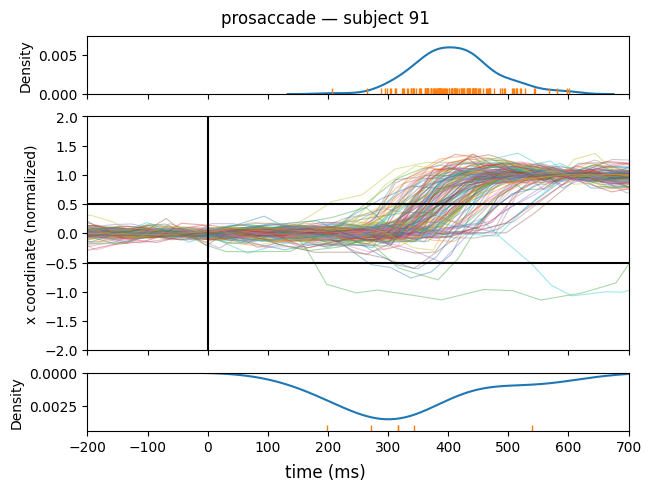

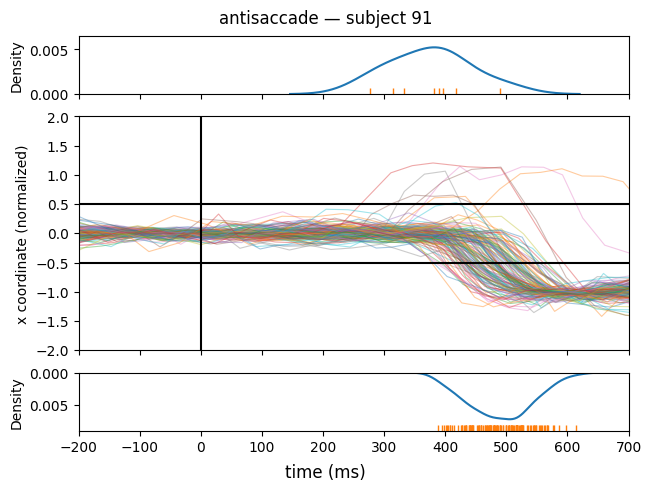

In [10]:
# Per-subject plot — change SUBJECT_ID to view a different subject
SUBJECT_ID = '0001'
old_id = id_map[SUBJECT_ID]

sub_samples = load_subject_samples(derivatives_path, SUBJECT_ID)

for stype in ['prosaccade', 'antisaccade']:
    res = analyze_antisaccade_subject(sub_samples, stype)
    plot_one_subject(
        ts_xs_ys=res['ts_xs_ys'],
        rt_errors=res['rt_errors'],
        rt_correct=res['rt_correct'],
        sacc_type=stype,
        subject_id=old_id,
    )


### 9 Group boxplots (error rate and RT)


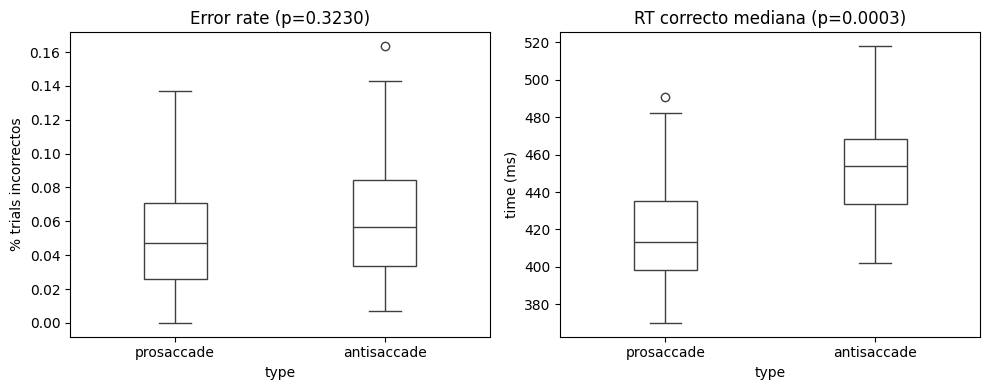

            error_rate                                    rt_correct_median  \
                 count mean  std  min  25%  50%  75%  max             count   
type                                                                          
antisaccade       26.0  0.1  0.0  0.0  0.0  0.1  0.1  0.2              26.0   
prosaccade        26.0  0.1  0.0  0.0  0.0  0.0  0.1  0.1              26.0   

                    ...               rt_error_median                       \
              mean  ...    75%    max           count   mean    std    min   
type                ...                                                      
antisaccade  454.7  ...  468.2  518.0            26.0  386.3   48.0  261.0   
prosaccade   418.8  ...  435.0  491.0            23.0  402.3  110.1  152.0   

                                         
               25%    50%    75%    max  
type                                     
antisaccade  363.9  383.5  413.5  475.0  
prosaccade   338.8  392.5  480.5  578.0  

[2

In [11]:
from scipy.stats import ranksums

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Error rate
ax = axes[0]
sns.boxplot(data=df_all, x="type", y="error_rate", width=0.3, ax=ax)
for patch in ax.patches: patch.set_facecolor("w")
p = ranksums(
    df_all[df_all["type"]=="prosaccade"]["error_rate"].dropna(),
    df_all[df_all["type"]=="antisaccade"]["error_rate"].dropna()
)[1]
ax.set_title(f"Error rate (p={p:.4f})")
ax.set_ylabel("% trials incorrectos")

# RT correcto
ax = axes[1]
sns.boxplot(data=df_all, x="type", y="rt_correct_median", width=0.3, ax=ax)
for patch in ax.patches: patch.set_facecolor("w")
p = ranksums(
    df_all[df_all["type"]=="prosaccade"]["rt_correct_median"].dropna(),
    df_all[df_all["type"]=="antisaccade"]["rt_correct_median"].dropna()
)[1]
ax.set_title(f"RT correcto mediana (p={p:.4f})")
ax.set_ylabel("time (ms)")

plt.tight_layout()
plt.show()

print(df_all.groupby("type")[["error_rate","rt_correct_median","rt_error_median"]].describe().round(1))


### 10 Group summary

In [12]:
df_all.groupby("type")[["n_valid", "error_rate", "rt_correct_median", "rt_error_median"]].mean().round(3)

,n_valid,error_rate,rt_correct_median,rt_error_median
type,,,,
antisaccade,134.923,0.063,454.692,386.288
prosaccade,136.346,0.051,418.808,402.283


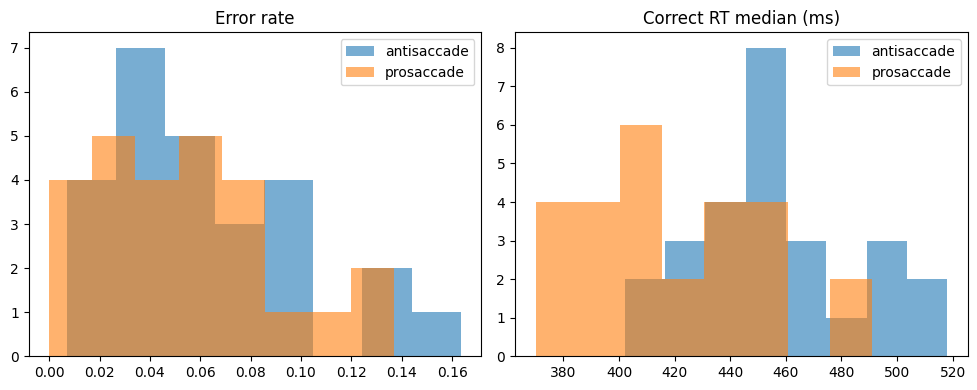

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
                                              
for ax, col, label in zip(axes,             
                         ["error_rate", "rt_correct_median"],               
                         ["Error rate", "Correct RT median (ms)"]):       
  for stype, grp in df_all.groupby("type"):                                 
      ax.hist(grp[col].dropna(), bins=8, alpha=0.6, label=stype)            
  ax.set_title(label)                                                       
  ax.legend()                                                               

plt.tight_layout()                                                            
plt.show()      

---
## Notes

- `_staging/` is temporary and can be deleted after BIDS generation.
- `_derivatives/` contains all pyxations output (one feather per subject).
- To re-run detection: pass `overwrite=True` to `compute_derivatives_for_dataset`.
- Antisaccade error classification is task-specific —
  pyxations detects eye movements, but correct/error logic remains in this notebook.
